Interpretation of selected best models.

# Libraries

In [44]:
import os
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.inspection import permutation_importance

In [45]:
RANDOM_STATE = 42

In [46]:
# train/test split
import sys
sys.path.insert(1, '../utils_functionality/split_utils/')
from split_tools import get_train_test

In [47]:
# dict with num features
sys.path.insert(1, '../utils_functionality/models/')
from modelling2_hyperparams import dict_num_features

# Data folder

In [48]:
path_interpretations = Path('../results/best_models_interpretations_modelling_2/')
if not os.path.exists(path_interpretations): os.makedirs(path_interpretations)

# Models interpretation

../results/models_modelling_2/logisticregression_splashing_df_modelling_dimensionless_onehot

In [49]:
target = 'splashing'
train, test = get_train_test(
    dataset_filename='df_modelling_dimensionless',
    target=target)
train = train[dict_num_features['df_modelling_dimensionless']+['wettability']+[target]]
test = test[dict_num_features['df_modelling_dimensionless']+['wettability']+[target]]

In [50]:
path_pipeline = r'../results/models_modelling_2/logisticregression_splashing_df_modelling_dimensionless_onehot'
pipeline = joblib.load(path_pipeline)

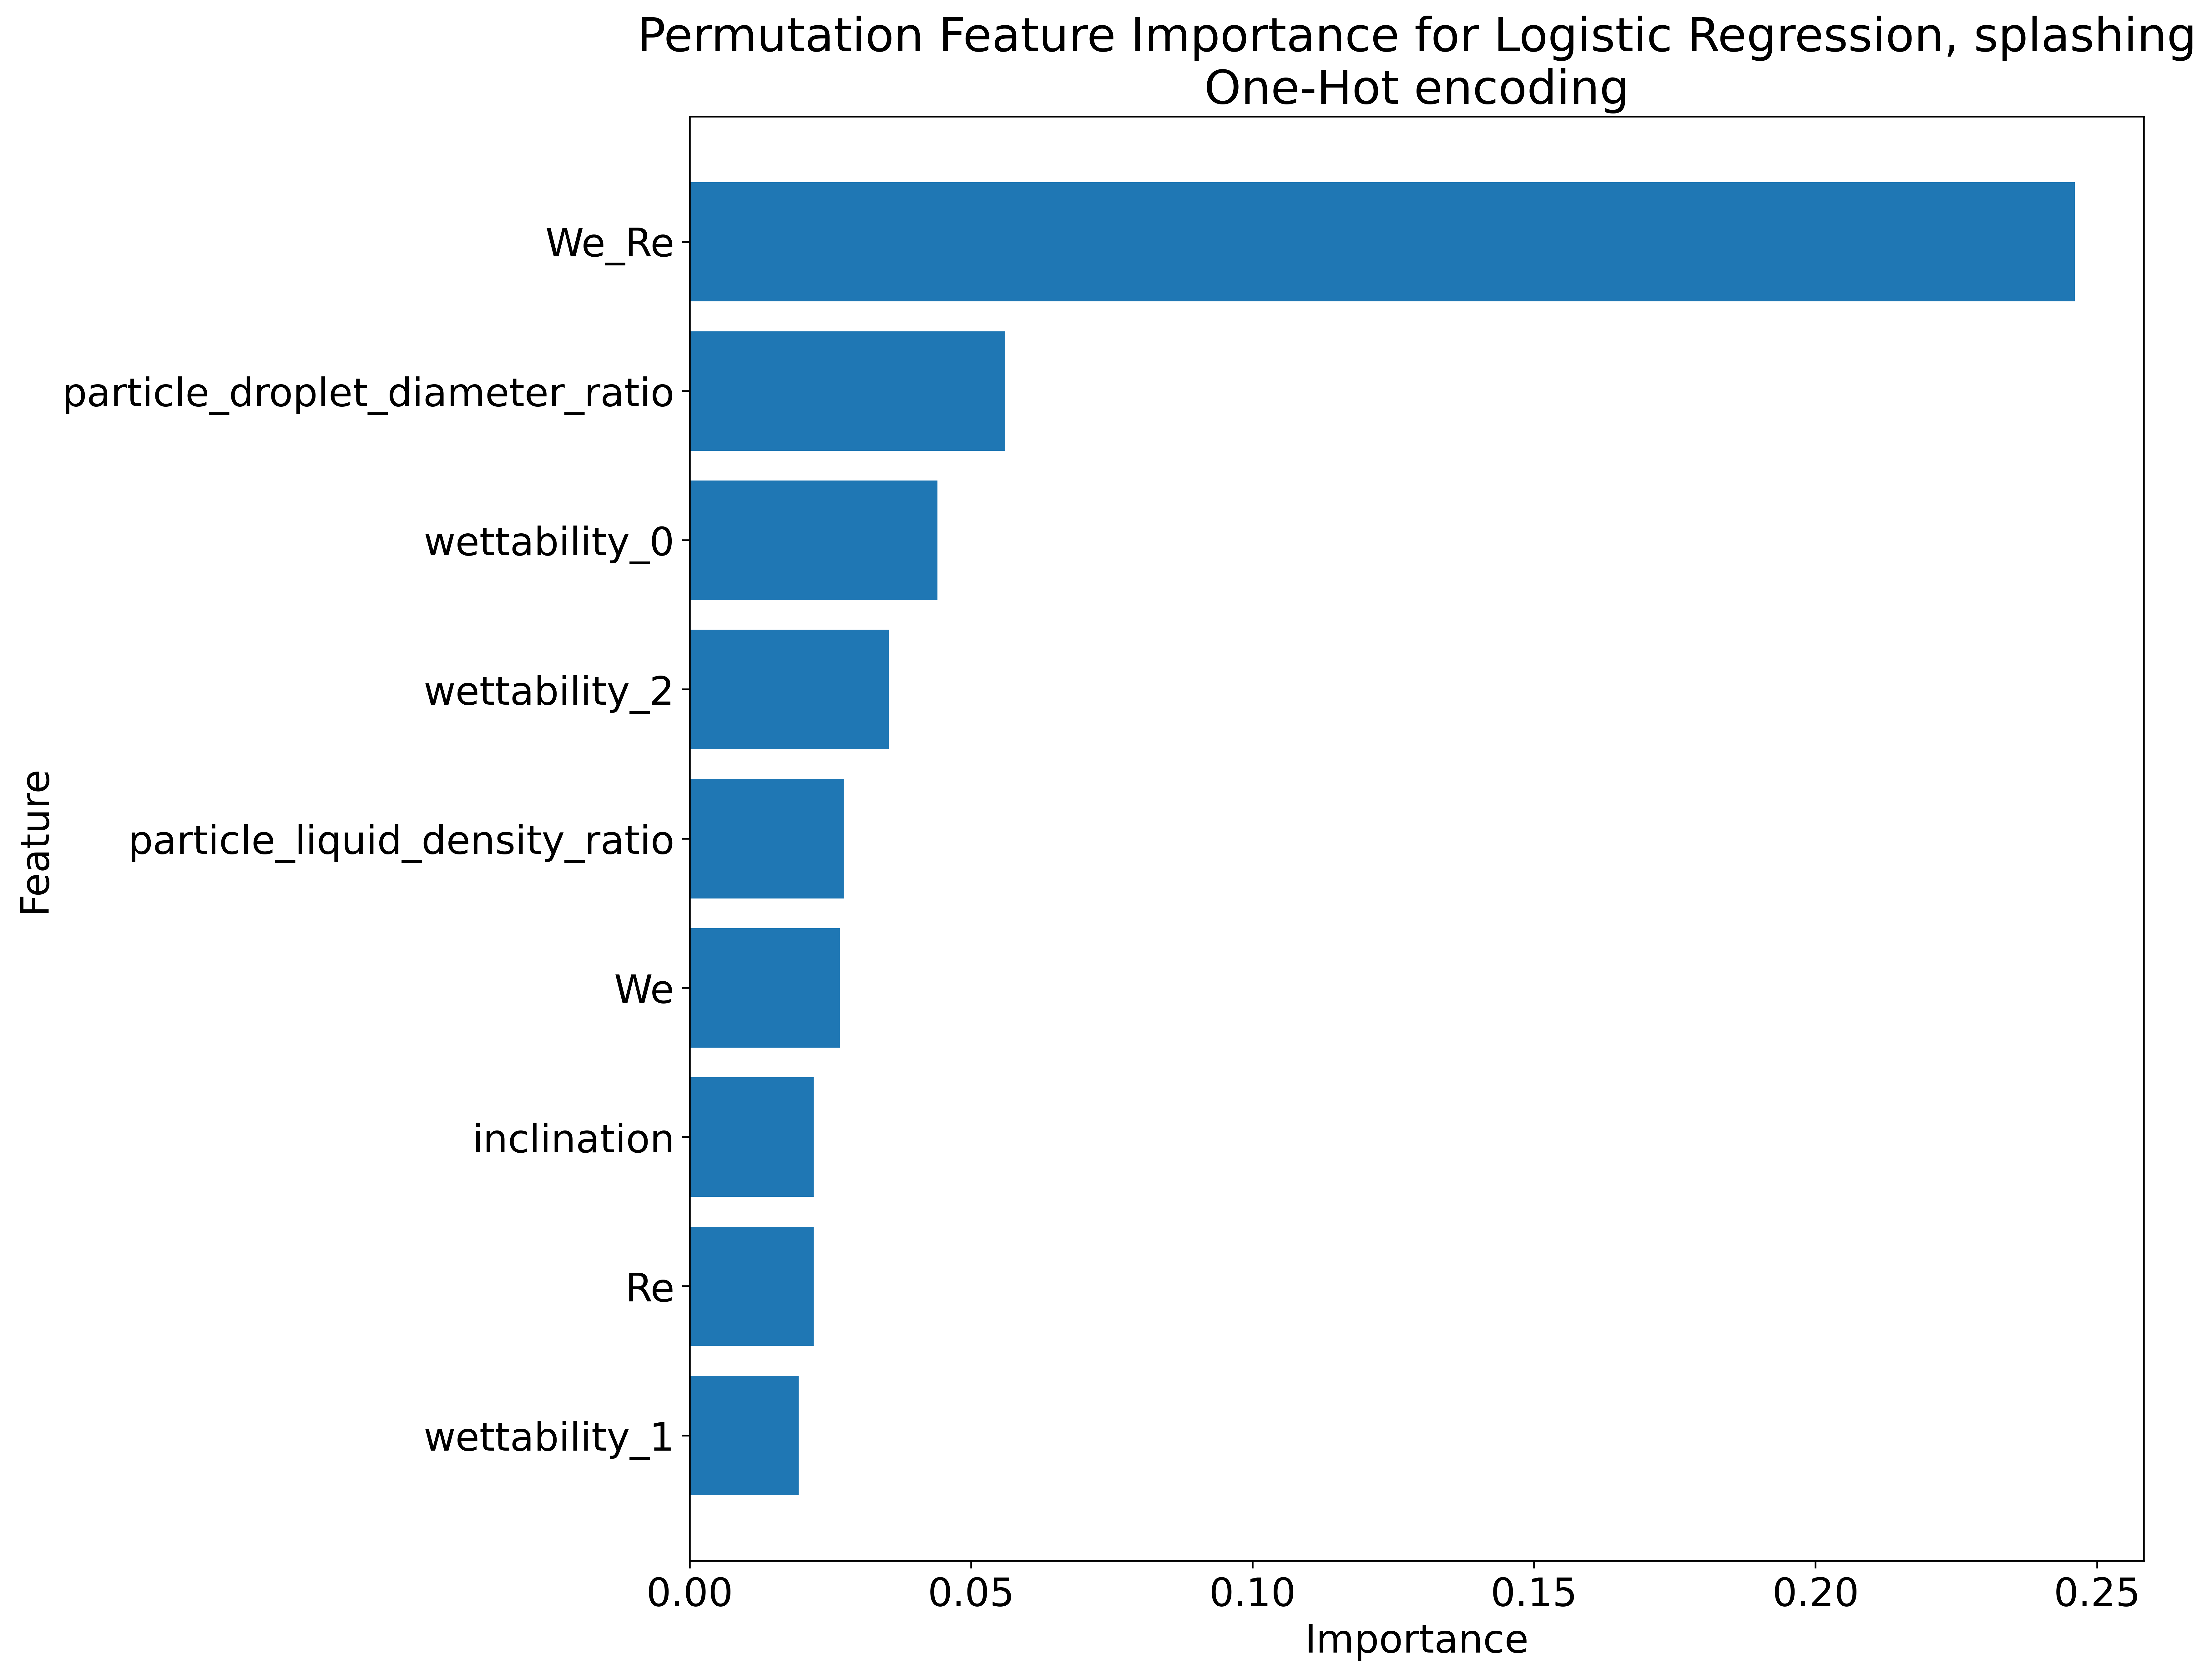

In [51]:
column_transformer = pipeline.steps[0][1].fit(train.drop(columns=[target]))
result = permutation_importance(
    estimator=pipeline.steps[1][1], 
    X=column_transformer.transform(test.drop(columns=[target])), 
    y=test[target], 
    n_repeats=20, 
    random_state=RANDOM_STATE)

importances = result.importances_mean
feature_names = column_transformer.get_feature_names_out()
feature_names = [x.split('__')[1] for x in feature_names]

df_permut_feature_importance = pd.DataFrame(
    {'Feature name': feature_names, 
     'Feature importance': importances}
).sort_values(by='Feature importance')

plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(12, 12),dpi=500)
plt.barh(
    y=df_permut_feature_importance['Feature name'],
    width=df_permut_feature_importance['Feature importance']
    )
plt.xlabel('Importance', fontsize=18)
plt.ylabel('Feature', fontsize=18)
plt.title(f'Permutation Feature Importance for Logistic Regression, {target}\nOne-Hot encoding')
plt.savefig(path_interpretations / f'logisticregression_splashing_df_modelling_dimensionless_onehot.pdf', bbox_inches='tight')
plt.show()

../results/models_modelling_2/logisticregression_net_impact_df_modelling_dimensionless_ordenc

In [52]:
target = 'net_impact'
train, test = get_train_test(
    dataset_filename='df_modelling_dimensionless',
    target=target)
train = train[dict_num_features['df_modelling_dimensionless']+['wettability']+[target]]
test = test[dict_num_features['df_modelling_dimensionless']+['wettability']+[target]]

In [53]:
path_pipeline = '../results/models_modelling_2/logisticregression_net_impact_df_modelling_dimensionless_ordenc'
pipeline = joblib.load(path_pipeline)

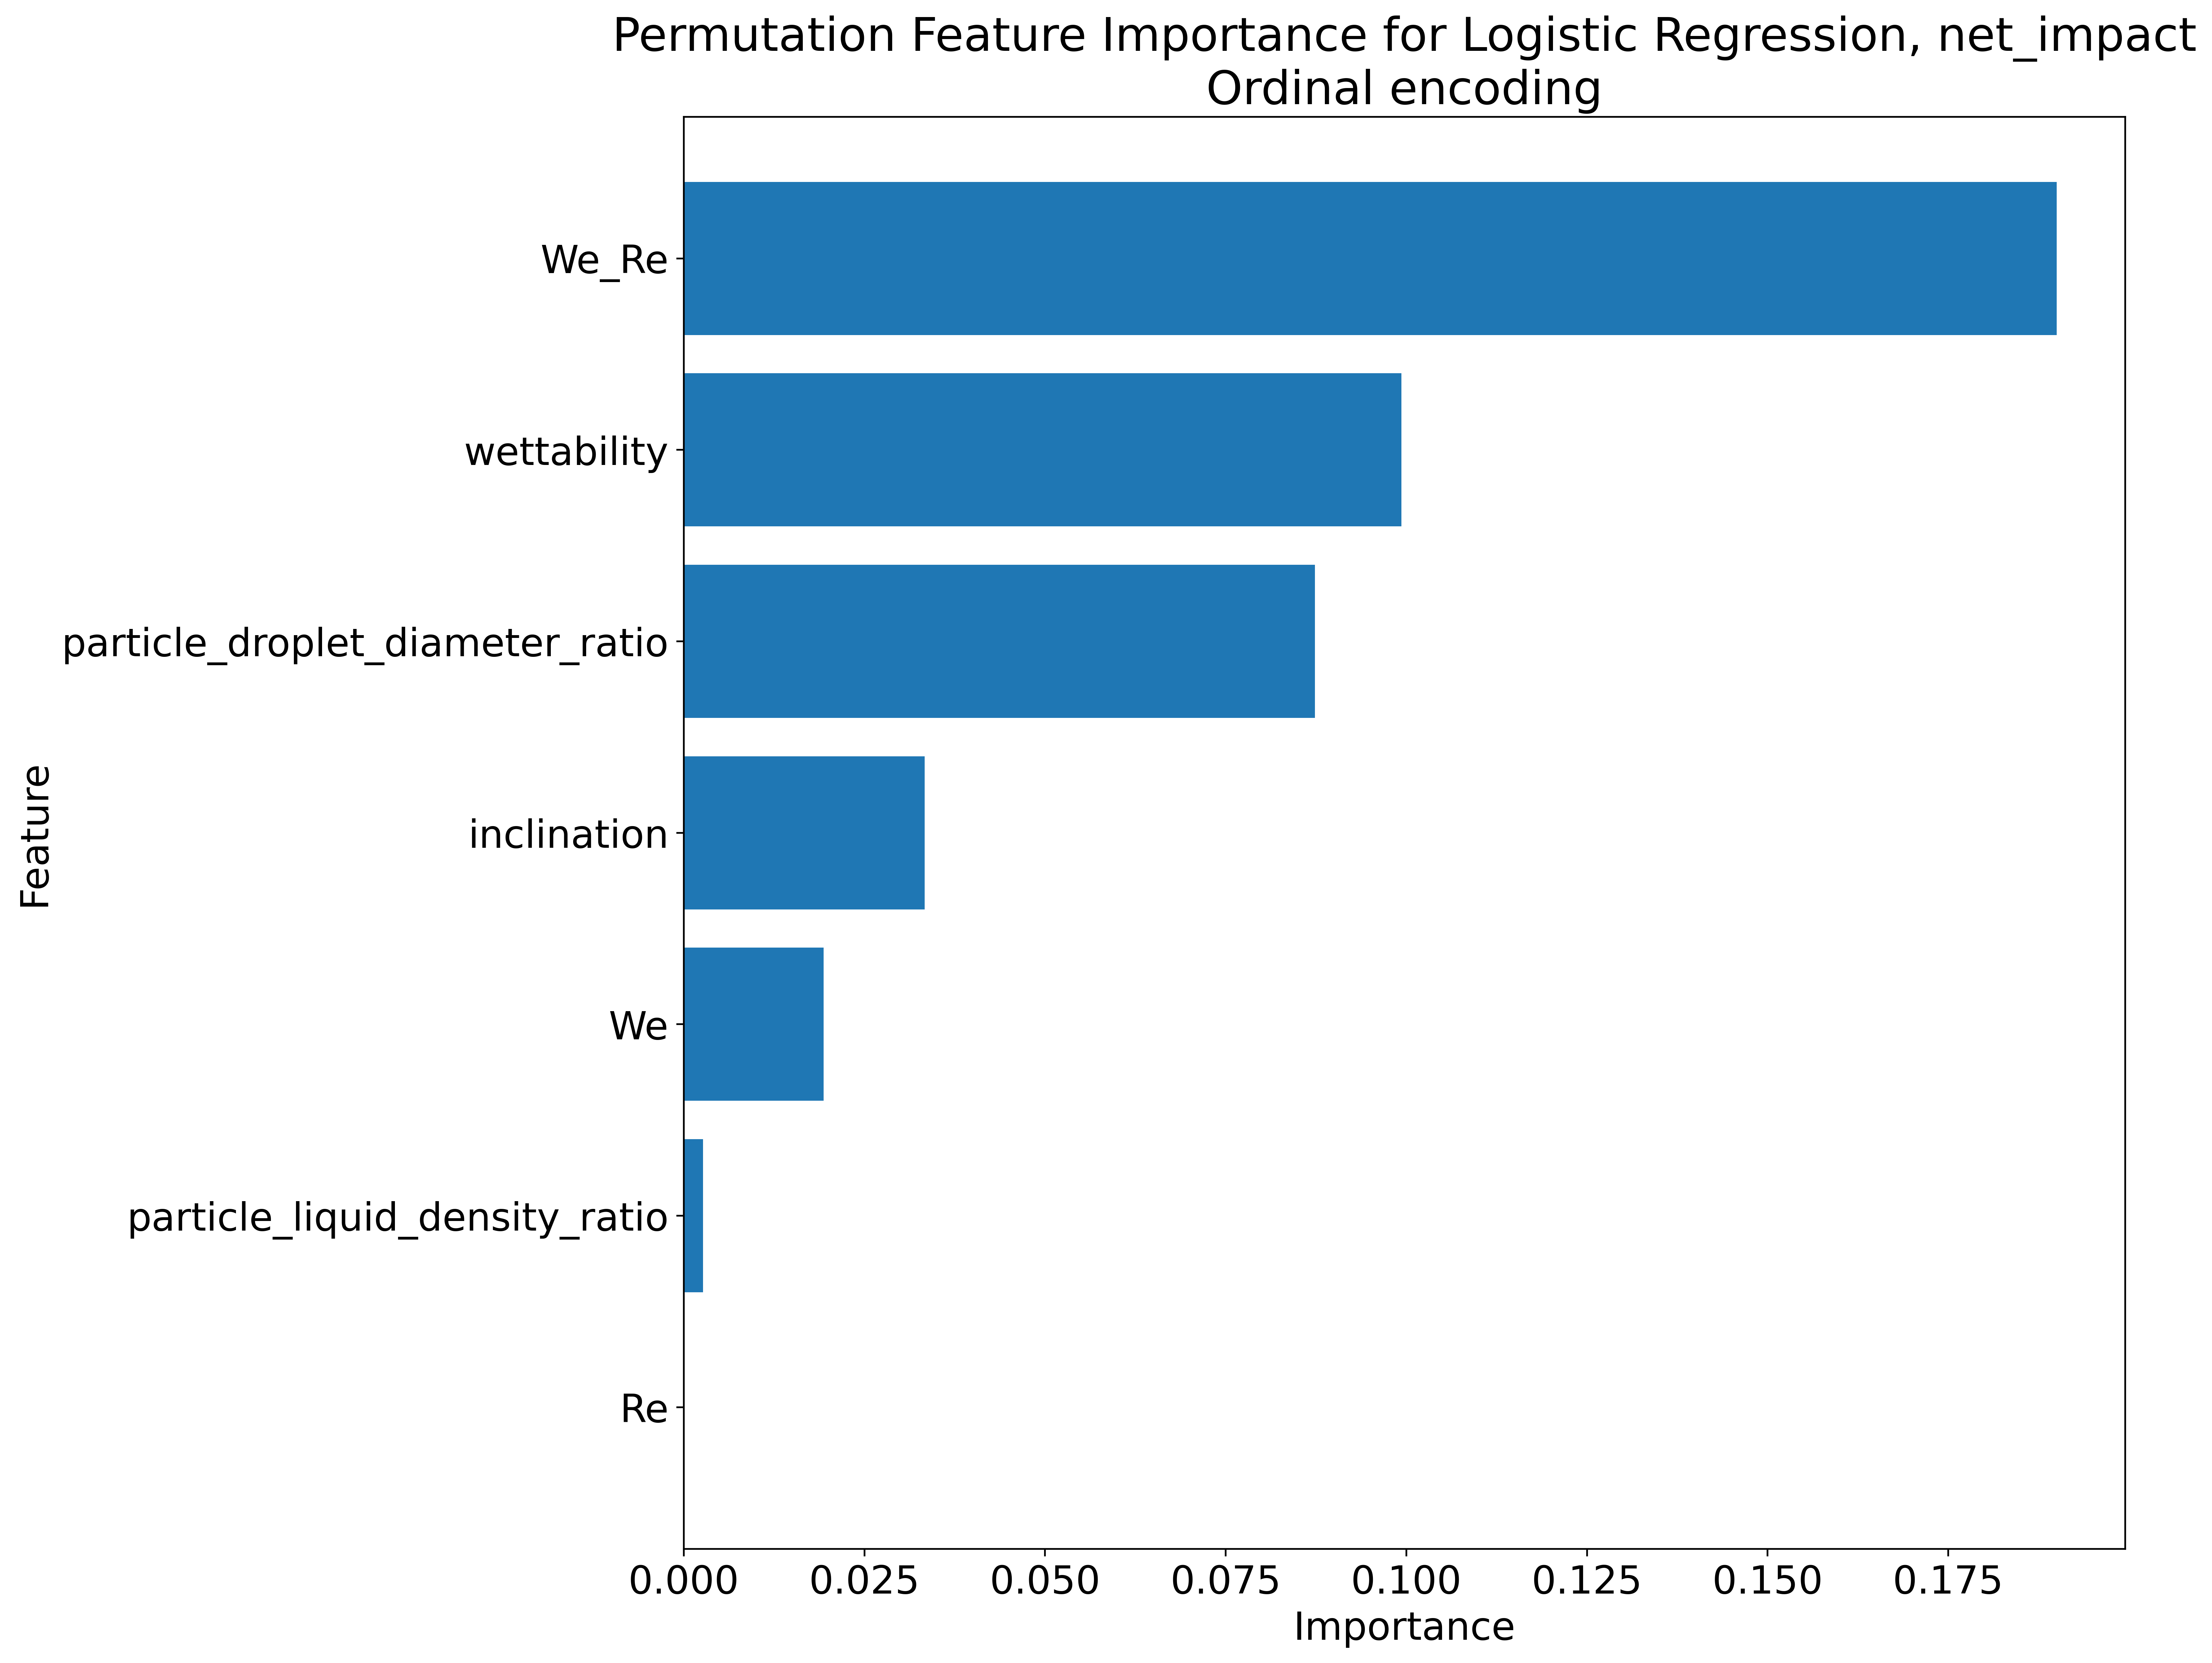

In [54]:
column_transformer = pipeline.steps[0][1].fit(train.drop(columns=[target]))
result = permutation_importance(
    estimator=pipeline.steps[1][1], 
    X=column_transformer.transform(test.drop(columns=[target])), 
    y=test[target], 
    n_repeats=20, 
    random_state=RANDOM_STATE)

importances = result.importances_mean
feature_names = column_transformer.get_feature_names_out()
feature_names = [x.split('__')[1] for x in feature_names]

df_permut_feature_importance = pd.DataFrame(
    {'Feature name': feature_names, 
     'Feature importance': importances}
).sort_values(by='Feature importance')

plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(12, 12),dpi=500)
plt.barh(
    y=df_permut_feature_importance['Feature name'],
    width=df_permut_feature_importance['Feature importance']
    )
plt.xlabel('Importance', fontsize=18)
plt.ylabel('Feature', fontsize=18)
plt.title(f'Permutation Feature Importance for Logistic Regression, {target}\nOrdinal encoding')
plt.savefig(path_interpretations / f'logisticregression_net_impact_df_modelling_dimensionless_ordenc.pdf', bbox_inches='tight')
plt.show()

../results/models_modelling_2/catboostclassifier_splashing_df_modelling_dimensionless

In [55]:
target = 'splashing'
train, test = get_train_test(
    dataset_filename='df_modelling_dimensionless',
    target=target)
train = train[dict_num_features['df_modelling_dimensionless']+['wettability']+[target]]
test = test[dict_num_features['df_modelling_dimensionless']+['wettability']+[target]]

In [56]:
path_pipeline = '../results/models_modelling_2/catboostclassifier_splashing_df_modelling_dimensionless'
pipeline = joblib.load(path_pipeline)

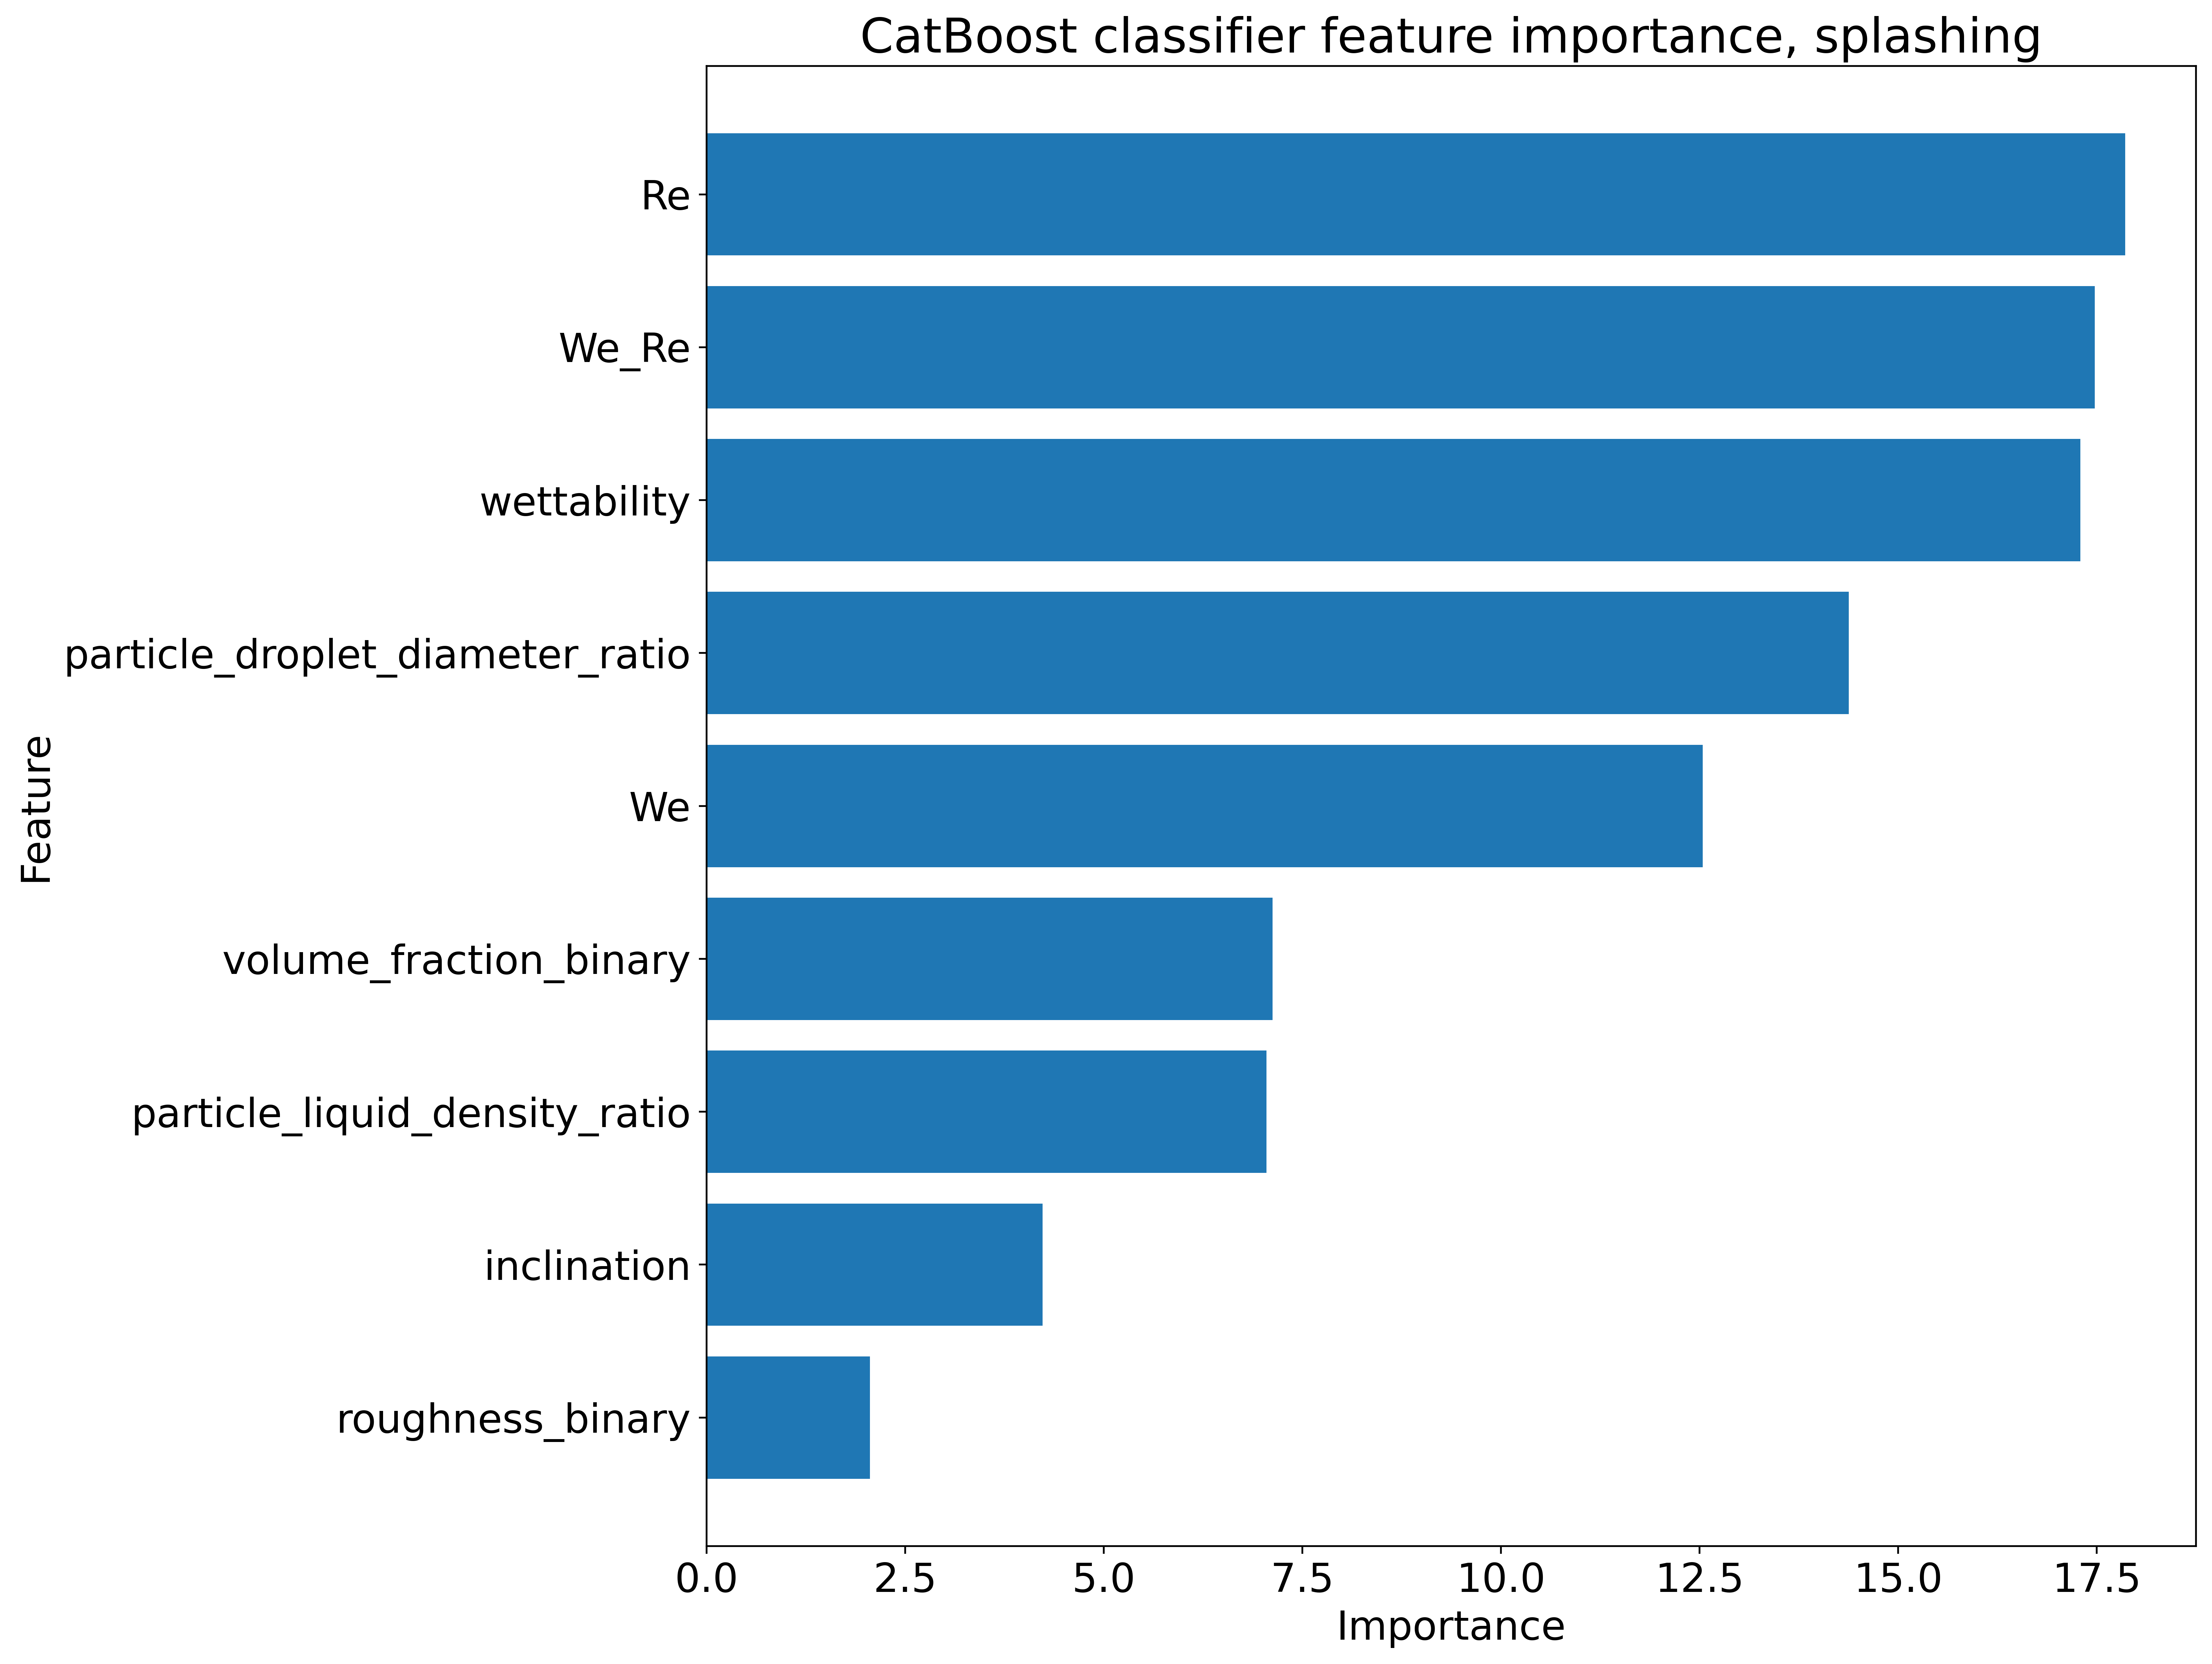

In [57]:
importances = pipeline.steps[0][1].feature_importances_
feature_names = pipeline.steps[0][1].feature_names_

df_permut_feature_importance = pd.DataFrame(
    {'Feature name': feature_names, 
     'Feature importance': importances}
).sort_values(by='Feature importance')

plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(12, 12),dpi=500)
plt.barh(
    y=df_permut_feature_importance['Feature name'],
    width=df_permut_feature_importance['Feature importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title(f'CatBoost classifier feature importance, {target}')

plt.savefig(path_interpretations / f'catboostclassifier_splashing_df_modelling_dimensionless.pdf', bbox_inches='tight')
plt.show()

../results/models_modelling_2/catboostclassifier_net_impact_df_modelling_dimensionless

In [58]:
target = 'net_impact'
train, test = get_train_test(
    dataset_filename='df_modelling_dimensionless',
    target=target)
train = train[dict_num_features['df_modelling_dimensionless']+['wettability']+[target]]
test = test[dict_num_features['df_modelling_dimensionless']+['wettability']+[target]]

In [59]:
path_pipeline = '../results/models_modelling_2/catboostclassifier_net_impact_df_modelling_dimensionless'
pipeline = joblib.load(path_pipeline)

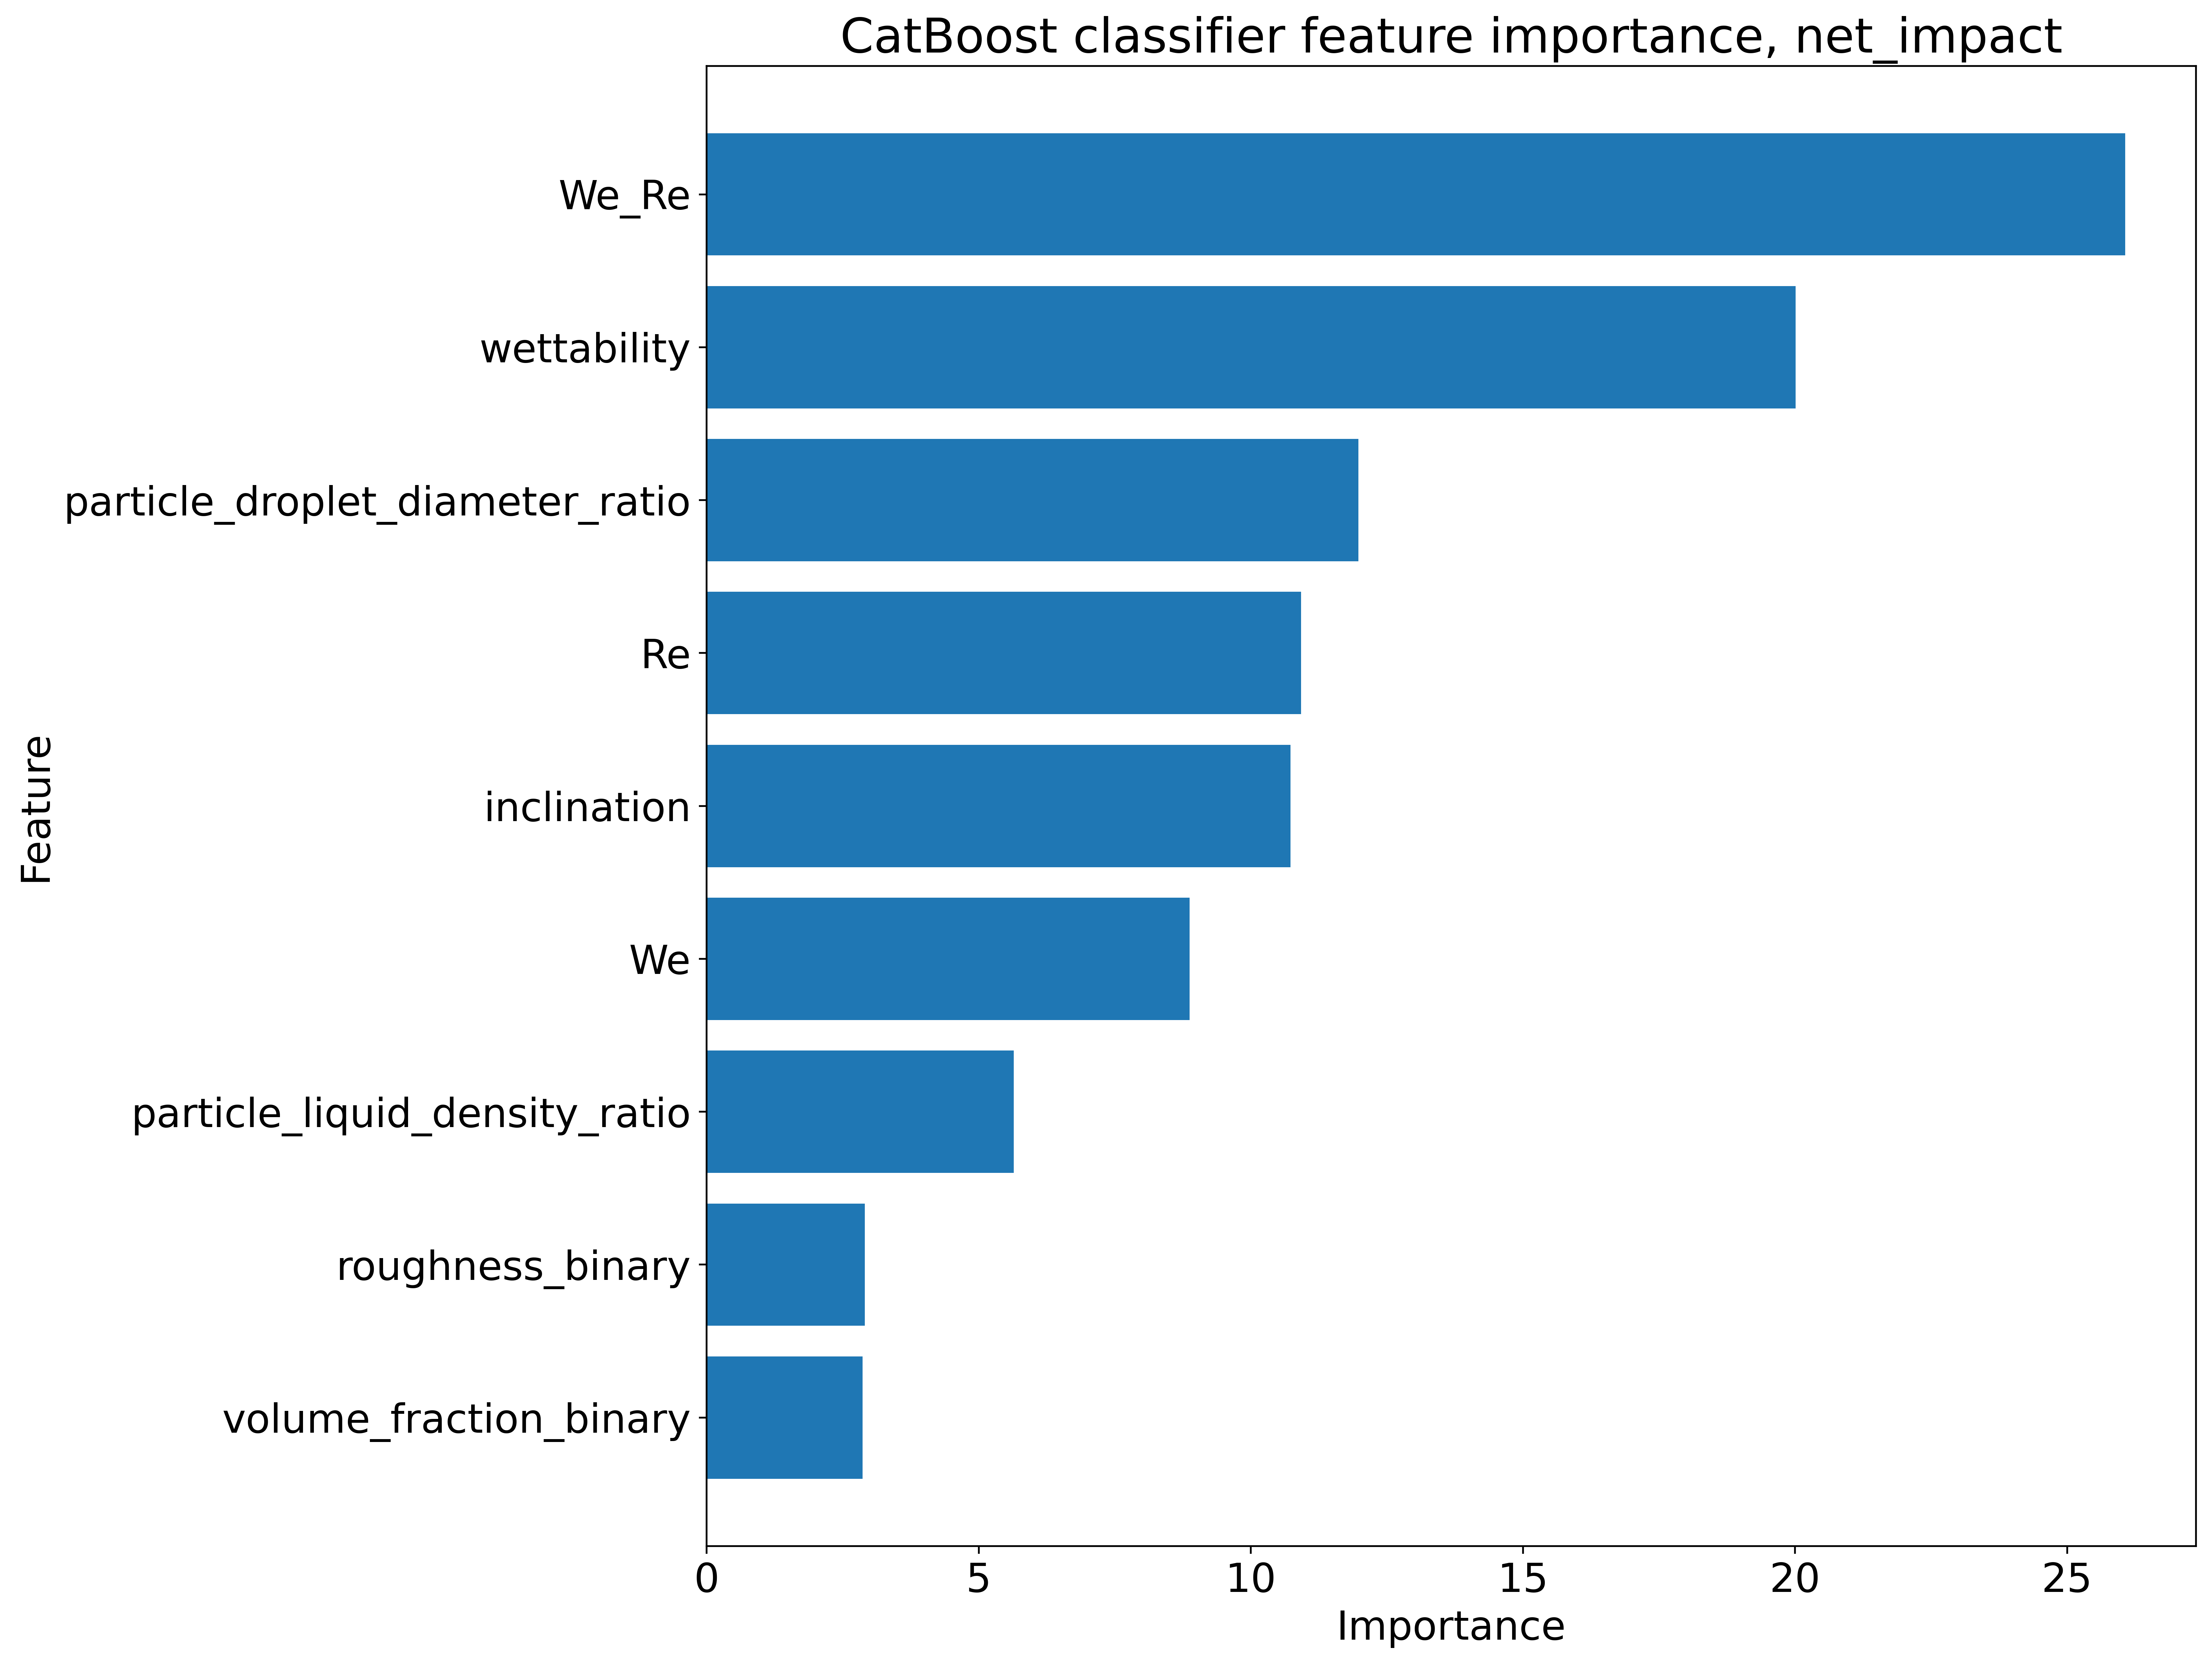

In [60]:
importances = pipeline.steps[0][1].feature_importances_
feature_names = pipeline.steps[0][1].feature_names_

df_permut_feature_importance = pd.DataFrame(
    {'Feature name': feature_names, 
     'Feature importance': importances}
).sort_values(by='Feature importance')

plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(12, 12),dpi=500)
plt.barh(
    y=df_permut_feature_importance['Feature name'],
    width=df_permut_feature_importance['Feature importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title(f'CatBoost classifier feature importance, net_impact')

plt.savefig(path_interpretations / f'catboostclassifier_net_impact_df_modelling_dimensionless.pdf', bbox_inches='tight')
plt.show()